# Q3 notebook

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

#encoding the data 
# weak/low/no = 0, strong/high/yes = 1
data = pd.DataFrame({
    "Wind": [0, 1, 0, 0, 1],       
    "Humidity": [1, 1, 0, 0, 0],   
    "Rain": [1, 1, 0, 1, 0]        
})

X = data[["Wind", "Humidity"]]
y = data["Rain"]

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_}\n")
print(f"Coefficients: {model.coef_}\n")

print(f"Predictions: {model.predict(X)}\n")

print(f"Probabilities: {model.predict_proba(X)}\n")

Intercept: [0.23498374]

Coefficients: [[-0.17918161  0.63088051]]

Predictions: [1 1 1 1 1]

Probabilities: [[0.29611559 0.70388441]
 [0.33477144 0.66522856]
 [0.4415229  0.5584771 ]
 [0.4415229  0.5584771 ]
 [0.48605309 0.51394691]]



## Conclusion

the model uses Wind and Humidity to estimate the probability of rain.

high humidity increases the chance of Rain = Yes in this dataset.

"weak + Low" case appears twice with different labels, so the model cannot classify both of those rows perfectly using only these two features.


# Q4

In [ ]:
CARBON_G_PER_KWH = 400
WATER_ML_PER_KWH = 500
# implementing the eco-impact calculation according to https://www.epa.gov/energy/greenhouse-gas-equivalencies-calculator
def eco_impact(efficient_wh, baseline_wh):
    efficient_kwh = efficient_wh / 1000
    return {
        "CO2 used (g)": round(efficient_kwh * CARBON_G_PER_KWH, 3),
        "Water used (mL)": round(efficient_kwh * WATER_ML_PER_KWH, 3),
        "Energy saved (%)": round((1 - efficient_wh / baseline_wh) * 100, 1)
}

## A) reflex agent for abnormal crowd movement

agent raises an alert when speed or direction changes cross a limit

In [3]:
def crowd_reflex_agent(speed_mps, direction_changes):
    abnormal = speed_mps > 2.5 or direction_changes > 4
    return "Alert security and record event" if abnormal else "Low-power monitoring"

crowd_cases = [(1.2, 2), (3.1, 3), (1.8, 6)]
pd.DataFrame([
    {"Speed (m/s)": speed, "Direction changes": changes,
     "Action": crowd_reflex_agent(speed, changes)}
    for speed, changes in crowd_cases
])

,Speed (m/s),Direction changes,Action
0,1.2,2,Low-power monitoring
1,3.1,3,Alert security and record event
2,1.8,6,Alert security and record event


## B) utility-based agent for stressed patients

agent scores each action by how closely it matches the patient's stress level, then applies a environmental cost

In [4]:
patient_actions = {
    "Guided breathing": {"target": 3, "eco_cost": 0.1},
    "Quiet room": {"target": 6, "eco_cost": 0.4},
    "Notify clinician": {"target": 9, "eco_cost": 0.8}
}

def patient_utility_agent(stress_level):
    utilities = {
        action: 10 - abs(stress_level - details["target"]) - details["eco_cost"]
        for action, details in patient_actions.items()
    }
    return max(utilities, key=utilities.get)

pd.DataFrame({
    "Stress level": [2, 6, 9],
    "Selected action": [patient_utility_agent(level) for level in [2, 6, 9]]
})

,Stress level,Selected action
0,2,Guided breathing
1,6,Quiet room
2,9,Notify clinician


## C) goal-based agent for a secure school-van commute

The goal is a verified driver, working GPS, enough seats, and a safety score of at least 0.90. Among routes that meet the goal, the shortest route reduces fuel use.

In [5]:
routes = [
    {"route": "A", "distance_km": 8.0, "safety": 0.82, "gps": True, "driver_verified": True, "seats": 12},
    {"route": "B", "distance_km": 9.5, "safety": 0.96, "gps": True, "driver_verified": True, "seats": 12},
    {"route": "C", "distance_km": 8.7, "safety": 0.93, "gps": True, "driver_verified": True, "seats": 10}
]

def school_van_goal_agent(route_options, students):
    secure = [
        route for route in route_options
        if route["safety"] >= 0.90
        and route["gps"]
        and route["driver_verified"]
        and route["seats"] >= students
    ]
    return min(secure, key=lambda route: route["distance_km"]) if secure else "No secure route"

school_van_goal_agent(routes, students=10)

{'route': 'C',
 'distance_km': 8.7,
 'safety': 0.93,
 'gps': True,
 'driver_verified': True,
 'seats': 10}

## D) learning agent to encourage sports

agent learns an average enjoyment score from feedback. 

In [6]:
class SportsLearningAgent:
    def __init__(self, activities):
        self.activities = activities
        self.total_reward = {name: 0 for name in activities}
        self.attempts = {name: 0 for name in activities}

    def learn(self, activity, enjoyment):
        self.total_reward[activity] += enjoyment
        self.attempts[activity] += 1

    def recommend(self):
        def score(activity):
            attempts = self.attempts[activity]
            enjoyment = self.total_reward[activity] / attempts if attempts else 0
            return enjoyment - self.activities[activity]["eco_cost"]
        return max(self.activities, key=score)

activities = {
    "Football": {"eco_cost": 0.10},
    "Cycling": {"eco_cost": 0.05},
    "Indoor gym": {"eco_cost": 0.40}
}
sports_agent = SportsLearningAgent(activities)

for activity, enjoyment in [("Football", 4), ("Cycling", 5), ("Indoor gym", 4), ("Cycling", 4)]:
    sports_agent.learn(activity, enjoyment)

sports_agent.recommend()

'Cycling'

## estimating environmental impact

In [7]:
eco_scenarios = [
    ("Reflex crowd agent", 0.20, 1.00),
    ("Patient utility agent", 0.08, 0.40),
    ("School-van goal agent", 0.10, 0.60),
    ("Sports learning agent", 0.06, 0.50)
]

eco_summary = pd.DataFrame([
    {"Agent": agent, **eco_impact(efficient_wh, baseline_wh)}
    for agent, efficient_wh, baseline_wh in eco_scenarios
])
eco_summary

,Agent,CO2 used (g),Water used (mL),Energy saved (%)
0,Reflex crowd agent,0.080,0.10,80.0
1,Patient utility agent,0.032,0.04,80.0
2,School-van goal agent,0.040,0.05,83.3
3,Sports learning agent,0.024,0.03,88.0


## Conclusion

The four agents make useful decisions with lightweight methods. They lower environmental impact by processing only necessary events, choosing proportionate patient support, selecting the shortest secure route, and learning from compact feedback data.

## Q8 plot

S = [7.25205261e+00 3.90503480e+02 7.78775427e+03 7.16990044e+04]


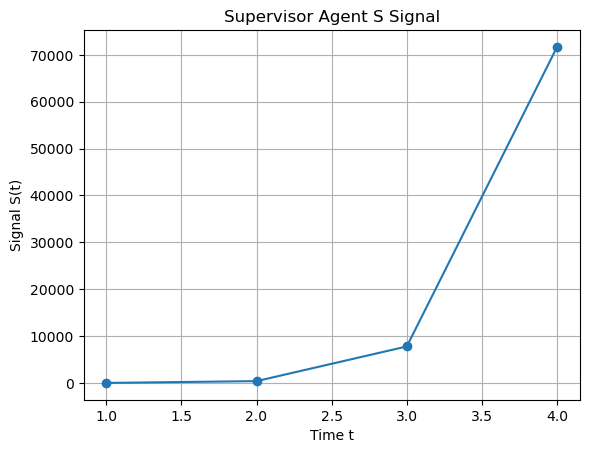

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.array([1, 2, 3, 4])

# Convert degrees to radians
rad = np.deg2rad(t)

A = 0.2*t + t**2
B = np.sin(rad) + np.cos(rad)
C = t**5 + t**6 + np.sin(rad)
D = t**5 + t**8 + np.sin(rad) + np.cos(rad)

S = A + B + C + D

print("S =", S)

plt.plot(t, S, marker="o")
plt.xlabel("Time t")
plt.ylabel("Signal S(t)")
plt.title("Supervisor Agent S Signal")
plt.grid(True)
plt.show()